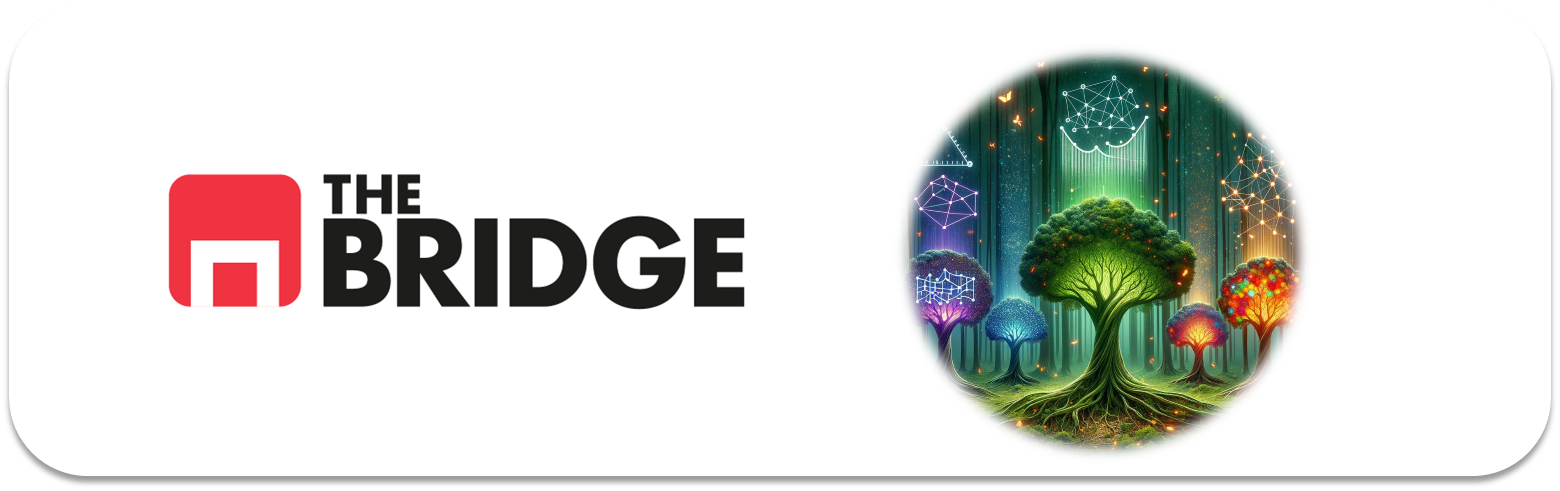

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
import sys
sys.path.append(r"c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\Apuntes")
from definiciones import describe_df, tipifica_variables

In [7]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
preg,int64,0.0,17,2.21
plas,int64,0.0,136,17.71
pres,int64,0.0,47,6.12
skin,int64,0.0,51,6.64
test,int64,0.0,186,24.22
mass,float64,0.0,248,32.29
pedi,float64,0.0,517,67.32
age,int64,0.0,52,6.77
class,int64,0.0,2,0.26


In [8]:
TARGET = 'class'  # ← Cambia esto por el nombre de tu columna objetivo

n_unique = df[TARGET].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET].describe())

Valores únicos en la target: 2
→ Posible CLASIFICACIÓN
class
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Es un problema de clasificación desbalanceado

In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 614 filas  (80 %)
Test:  154 filas  (20 %)


In [10]:
# Tipos de datos
print(X_train.dtypes)
print()

# Valores faltantes
missing = X_train.isna().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
resumen = pd.DataFrame({'count': missing, '%': missing_pct})
print(resumen[resumen['count'] > 0].sort_values('%', ascending=False))
print()

# Duplicados
print(f"Duplicados: {X_train.duplicated().sum()}")

preg      int64
plas      int64
pres      int64
skin      int64
test      int64
mass    float64
pedi    float64
age       int64
dtype: object

Empty DataFrame
Columns: [count, %]
Index: []

Duplicados: 0


In [14]:
features_num = X_train.columns.tolist()
features_num

['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

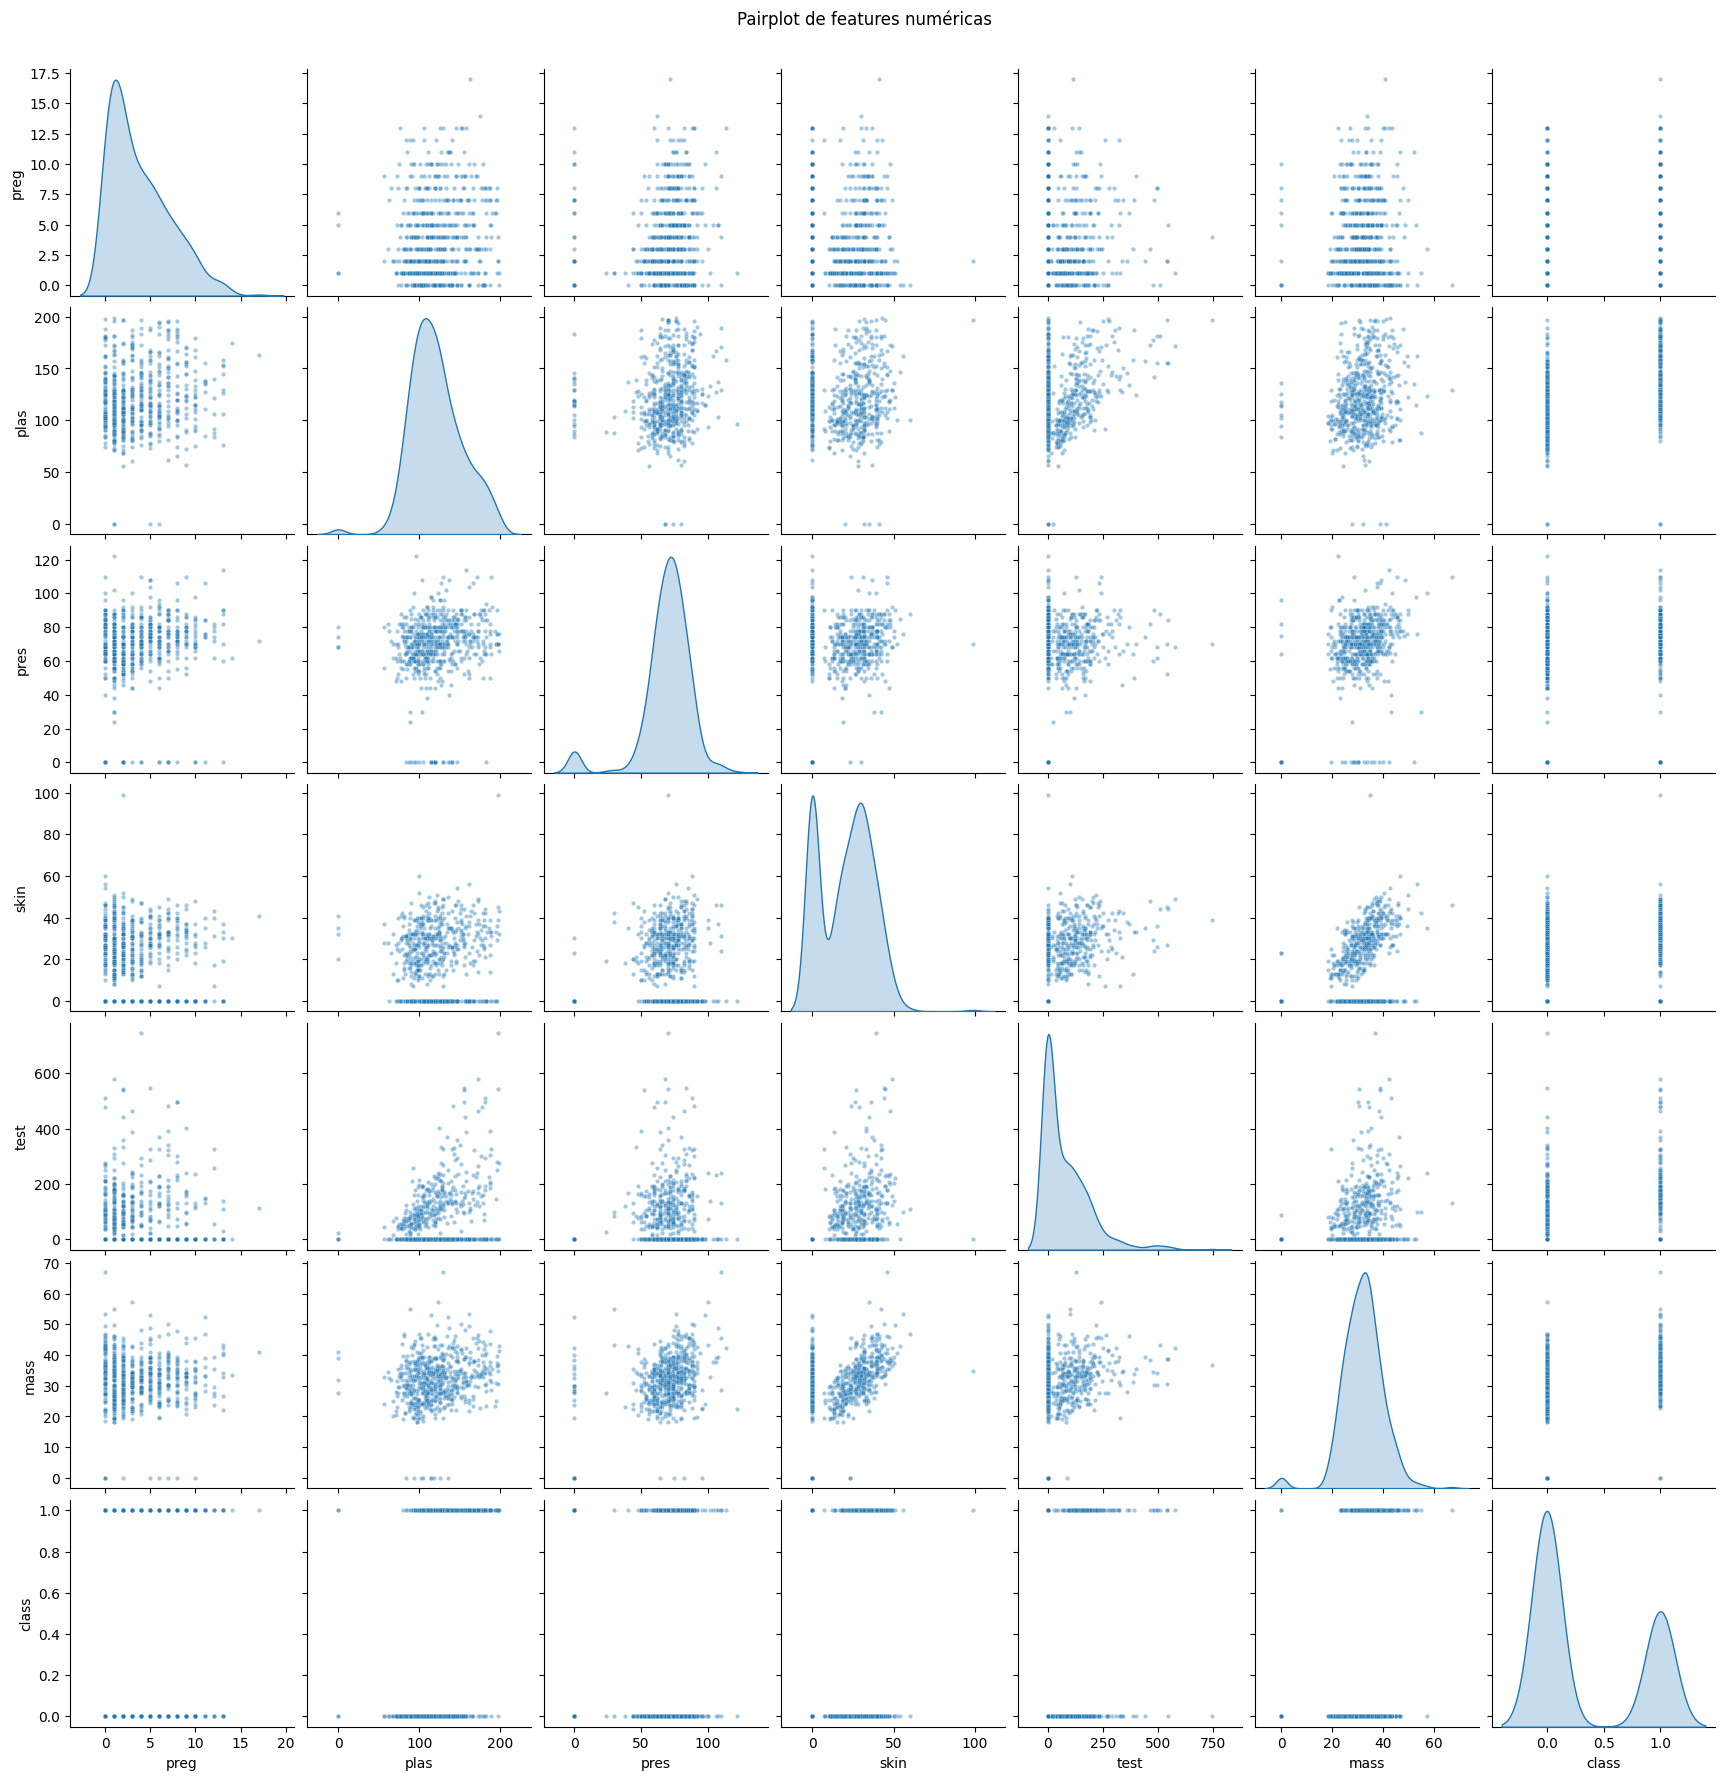

In [11]:
# Seleccionamos las features numéricas y añadimos la target
cols_plot = X_train.select_dtypes('number').columns.tolist()[:6]  # max 6 para legibilidad

sns.pairplot(
    X_train[cols_plot].join(y_train),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)
plt.suptitle('Pairplot de features numéricas', y=1.02)
plt.show()

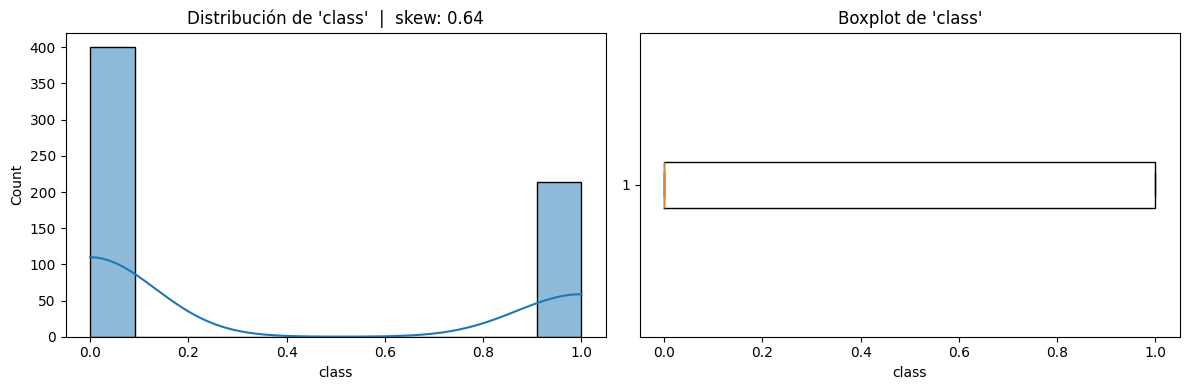

class
0    65.1
1    34.9
Name: proportion, dtype: float64


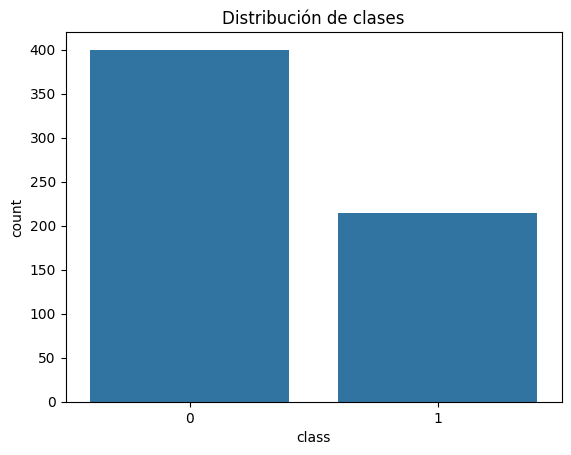

In [16]:
# Estudiamos la TARGET

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con curva de densidad
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de '{TARGET}'  |  skew: {y_train.skew():.2f}")

# Boxplot para ver outliers
axes[1].boxplot(y_train.dropna(), vert=False)
axes[1].set_title(f"Boxplot de '{TARGET}'")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

# Para clasificación — descomenta esto:
sns.countplot(x=y_train)
plt.title('Distribución de clases')
print(y_train.value_counts(normalize=True).mul(100).round(1))

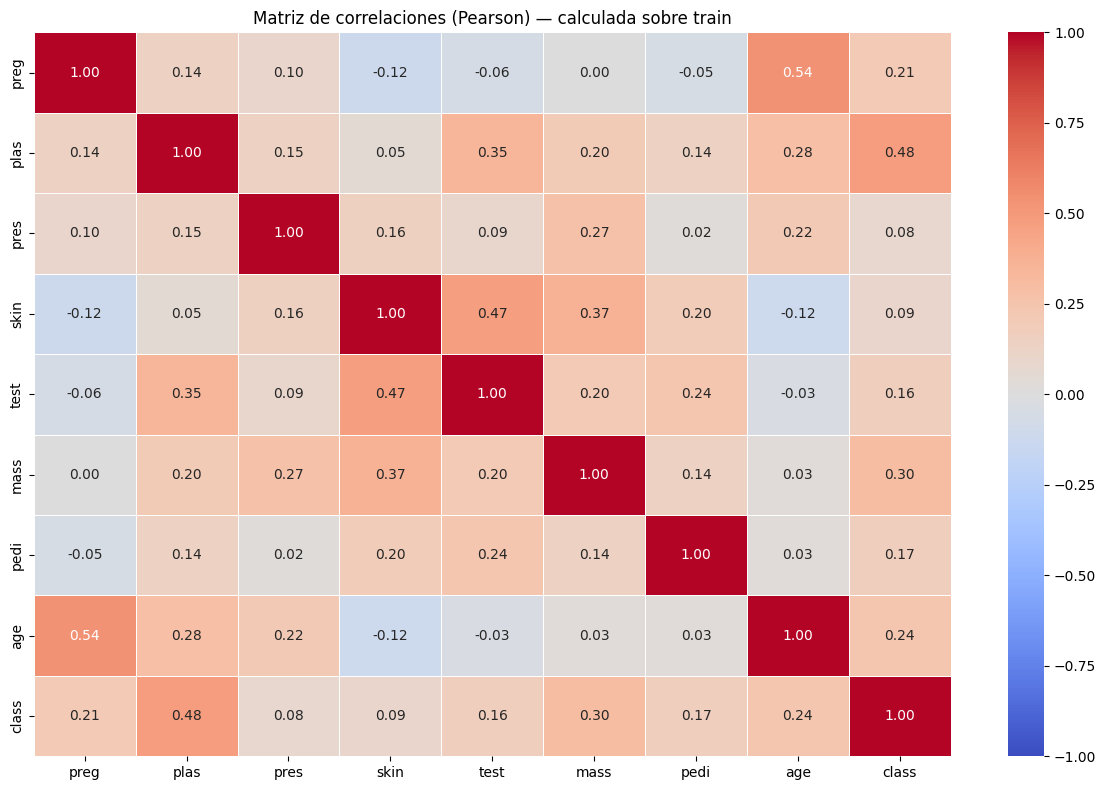


Correlación con la target:
plas    0.479330
mass    0.301422
age     0.240676
preg    0.208173
pedi    0.165312
test    0.164197
skin    0.093789
pres    0.082383


In [17]:
# Hacemos la matriz de correlaciones con nuestras variables numéricas

corr = X_train.join(y_train).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson) — calculada sobre train')
plt.tight_layout()
plt.show()

# Correlación de cada feature con la target, ordenada
print("\nCorrelación con la target:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_string())

In [20]:
X_train.describe()

,preg,plas,pres,skin,test,mass,pedi,age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,120.908795,69.442997,20.776873,78.666124,31.973290,0.477428,33.366450
std,3.314148,31.561093,18.402581,15.856433,107.736572,7.861364,0.330300,11.833438
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084000,21.000000
25%,1.000000,99.000000,62.500000,0.000000,0.000000,27.500000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,23.000000,40.500000,32.300000,0.382500,29.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


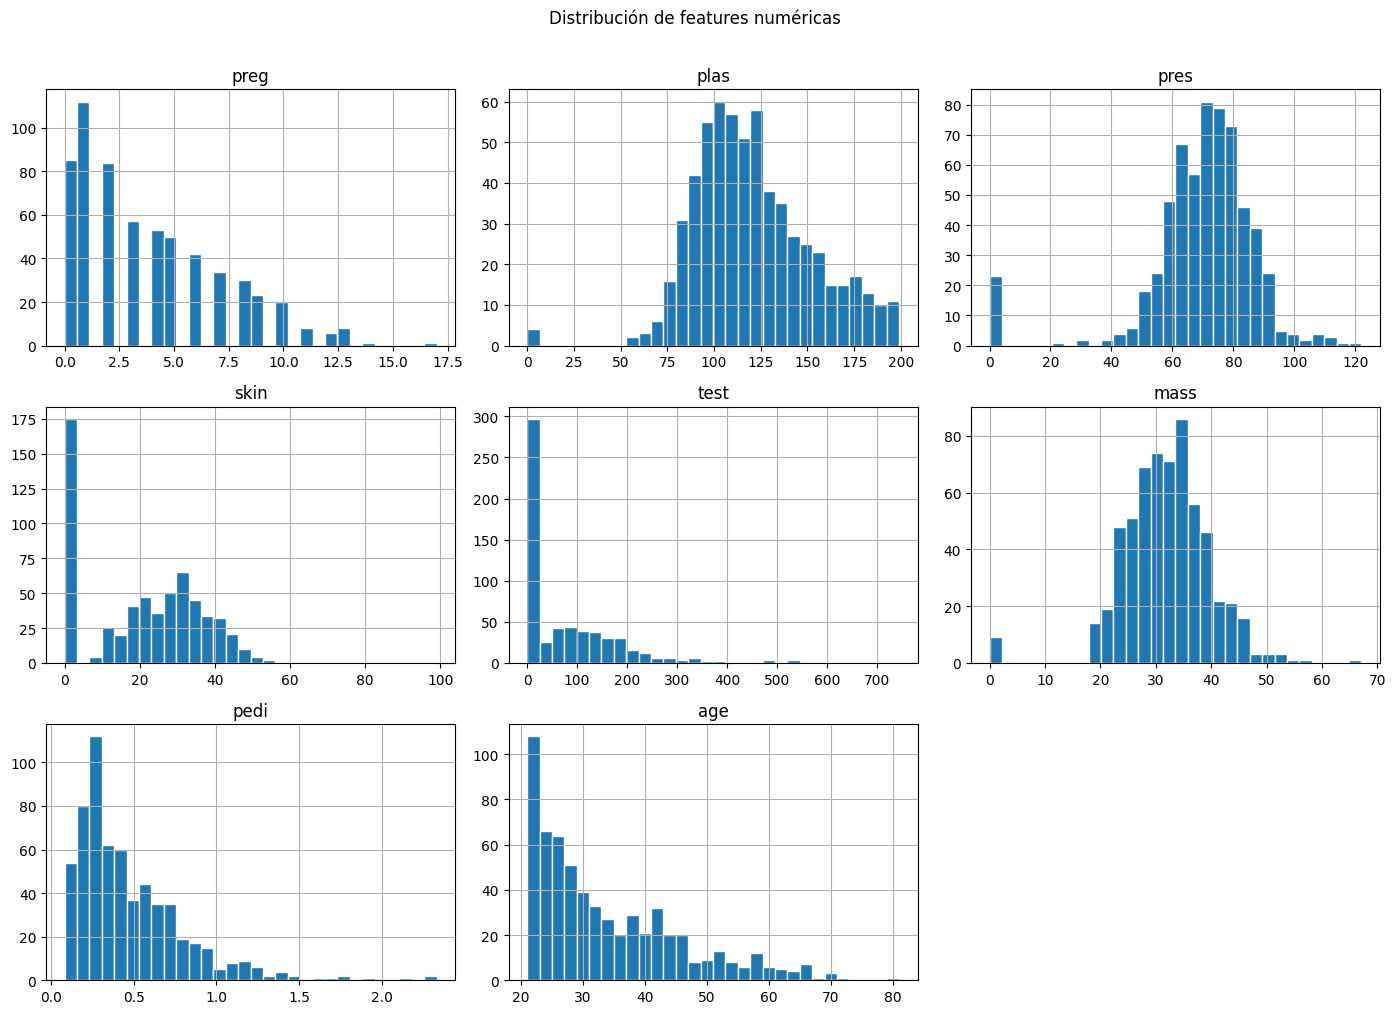

Skewness (asimetria) por feature:
test    2.026544
pedi    1.818910
pres   -1.789236
age     1.128456
preg    0.886920
mass   -0.478416
plas    0.176053
skin    0.107733


In [18]:
# Análisis univariante de nuestras features numéricas

X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness (asimetria) por feature:")
print(skew.to_string())

In [21]:
# asimetría alta positiva → log1p
for col in ['test', 'pedi', 'age']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

# asimetría alta negativa → cbrt
X_train['pres'] = np.cbrt(X_train['pres'])
X_test['pres']  = np.cbrt(X_test['pres'])

# asimetría media → sqrt
X_train['preg'] = np.sqrt(X_train['preg'])
X_test['preg']  = np.sqrt(X_test['preg'])


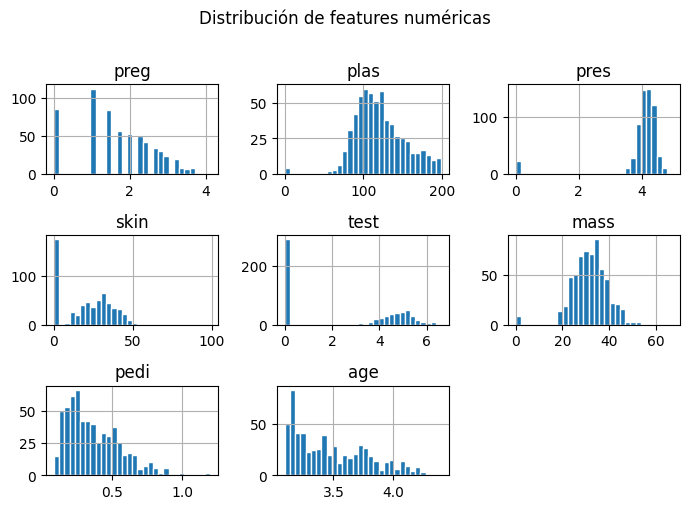

In [ ]:
# Visualización despues de la transformación

X_train.select_dtypes('number').hist(figsize=(7, 5), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()


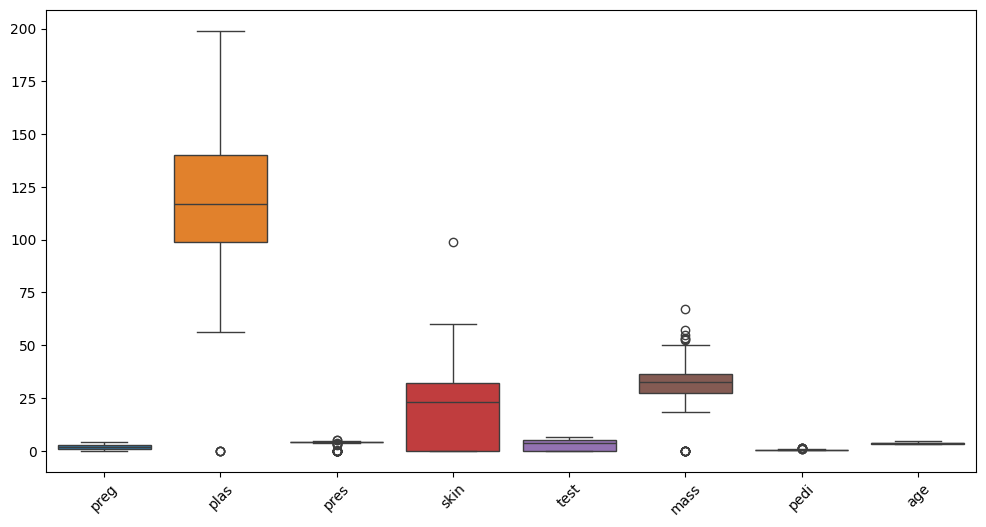

In [24]:
# Boxplot para visualizar si hay outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train)
plt.xticks(rotation=45)
plt.show()


In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [29]:
# Creo este diccionario para que se guarden las métricas
metricas_optimizadas = {}

In [32]:
# BAGGING

# RANDOM FOREST, MÉTRICA 

rf_clf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [2, 4, 10, None],
    "min_samples_leaf": [5, 10, 20, 40],
    "max_features": ["sqrt", "log2", None]
}

rf_grid = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

print("RF best_score (F1):", rf_grid.best_score_)
metricas_optimizadas["RandomForest"] = rf_grid.best_score_


RF best_score (F1): 0.6683154039012452


In [33]:
# BOOSTING
from xgboost import XGBClassifier


xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
)

param_grid = {
    "max_depth": [2, 3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators": [100, 200, 400, 600],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1, 5]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42
)

xgb_grid.fit(X_train, y_train)

print("XGB best_score (F1):", xgb_grid.best_score_)
metricas_optimizadas["XGBoost"] = xgb_grid.best_score_


XGB best_score (F1): 0.6810071154898741


In [30]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier(
    objective="binary",
    random_state=42,
    class_weight="balanced",
    verbose=-100
)

param_grid = {
    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, -1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.6, 0.8, 1.0],          # antes bagging_fraction
    "colsample_bytree": [0.6, 0.8, 1.0],   # antes feature_fraction
    "min_child_samples": [5, 10, 20],
    "max_bin": [125, 255]
}

lgb_grid = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42
)

lgb_grid.fit(X_train, y_train)

print("LightGBM best_score (F1):", lgb_grid.best_score_)
metricas_optimizadas["LightGBM"] = lgb_grid.best_score_


LightGBM best_score (F1): 0.675959595959596


In [34]:
metricas_optimizadas

{'LightGBM': np.float64(0.675959595959596),
 'RandomForest': np.float64(0.6683154039012452),
 'XGBoost': np.float64(0.6810071154898741)}

In [35]:
# MÉTODO SELECCIONADO XGBOOST
best_xgb = xgb_grid.best_estimator_
best_xgb


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [36]:
#ENTRENAMOS EL MODELO CON ESTOS HIPERPARÁMETROS
best_xgb.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [37]:
# PREDECIMOS CONTRA EL TEST
y_pred = best_xgb.predict(X_test)


In [41]:
# Evaluación del test

print("F1 en test:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


F1 en test: 0.7096774193548387

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.74      0.80       100
           1       0.63      0.81      0.71        54

    accuracy                           0.77       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.79      0.77      0.77       154


Matriz de confusión:
[[74 26]
 [10 44]]
